# Research Question 1: Qualifying-Race Performance Correlation

**ST312 Project - Candidates: 60276, 61881**

## Research Question
*"What is the relationship between qualifying session performance metrics and final race standings across different circuits, seasons, and regulatory eras?"*

### Sub-questions:
1. Does the qualifying-race relationship change depending on circuit type and overtaking difficulty?
2. Do the regulations affecting overtaking introduced in 2022 affect the qualifying-race correlation?

## Approach
This notebook focuses on **exploratory data analysis** through visualization and descriptive statistics:
- Load qualifying and race data for 2022-2024
- Calculate Spearman correlations overall and by subgroups
- Visualize position changes by circuit type
- Examine pole position conversion rates
- Compare correlation strength across years

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import data_utils as du

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

Load qualifying and race data for 2022-2024 seasons (current ground-effect regulation era).

In [5]:
# Define years to analyze (2022-2024: current regulation era)
YEARS = [2022, 2023, 2024]

# Load data (this may take 10-20 minutes on first run)
print("Loading qualifying and race data...")
print("Note: First run will take time to download and cache data.")
print("Subsequent runs will be much faster using cached data.\n")

df = du.load_qualifying_race_data(YEARS)

Loading qualifying and race data...
Note: First run will take time to download and cache data.
Subsequent runs will be much faster using cached data.


Loading 2022 season data...


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


  Processing Bahrain Grand Prix... 

req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

✓
  Processing Saudi Arabian Grand Prix... 

...

Error loading 2022 Abu Dhabi Grand Prix Q: Failed to load any schedule data.
Quali failed

Loading 2023 season data...


logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


Error loading schedule for 2023: Failed to load any schedule data.

Loading 2024 season data...


logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


Error loading schedule for 2024: Failed to load any schedule data.

Loaded 219 driver-race observations


In [6]:
# Display data summary
du.print_data_summary(df, "RQ1: Qualifying-Race Data Summary")

# Show first few rows
print("Sample data:")
df.head(10)


RQ1: Qualifying-Race Data Summary
Total observations: 219
Date range: 2022 - 2022
Number of unique races: 11
Number of unique drivers: 21
Number of unique teams: 10

Sample data:


,year,race,driver,team,quali_pos,race_pos,grid_pos,circuit_type,position_change
0,2022,Bahrain Grand Prix,LEC,Ferrari,1,1,1,technical,0
1,2022,Bahrain Grand Prix,VER,Red Bull Racing,2,19,2,technical,17
2,2022,Bahrain Grand Prix,SAI,Ferrari,3,2,3,technical,-1
3,2022,Bahrain Grand Prix,PER,Red Bull Racing,4,18,4,technical,14
4,2022,Bahrain Grand Prix,HAM,Mercedes,5,3,5,technical,-2
5,2022,Bahrain Grand Prix,BOT,Alfa Romeo,6,6,6,technical,0
6,2022,Bahrain Grand Prix,MAG,Haas F1 Team,7,5,7,technical,-2
7,2022,Bahrain Grand Prix,ALO,Alpine,8,9,8,technical,1
8,2022,Bahrain Grand Prix,RUS,Mercedes,9,4,9,technical,-5
9,2022,Bahrain Grand Prix,GAS,AlphaTauri,10,20,10,technical,10


## 2. Overall Correlation Analysis

Calculate the overall correlation between qualifying position and race position.

In [7]:
# Calculate Spearman correlation
overall_corr, p_value = stats.spearmanr(df['quali_pos'], df['race_pos'])

print(f"Overall Qualifying-Race Correlation (2022-2024)")
print(f"="*50)
print(f"Spearman correlation: {overall_corr:.3f}")
print(f"P-value: {p_value:.2e}")
print(f"Number of observations: {len(df)}")
print(f"\nInterpretation: {'Strong' if overall_corr > 0.7 else 'Moderate' if overall_corr > 0.5 else 'Weak'} positive correlation")

Overall Qualifying-Race Correlation (2022-2024)
Spearman correlation: 0.548
P-value: 1.44e-18
Number of observations: 219

Interpretation: Moderate positive correlation


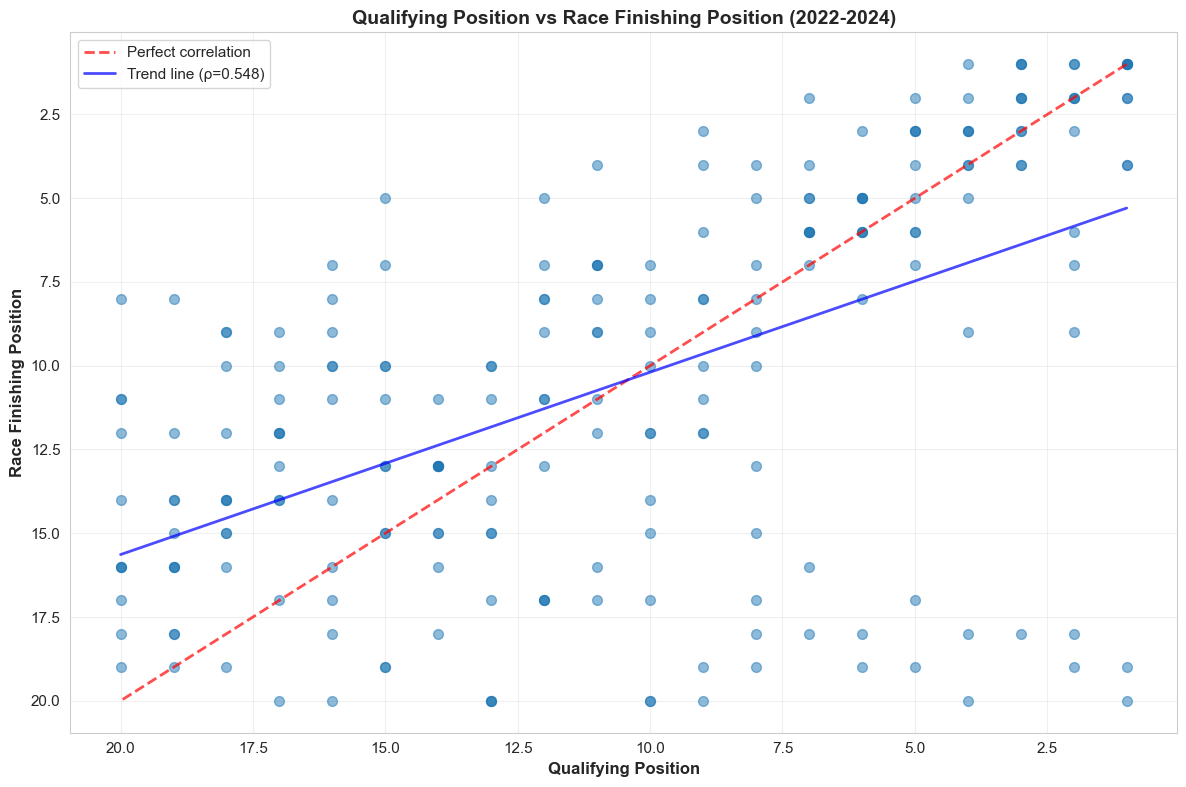

In [8]:
# Scatter plot: Qualifying position vs Race position
fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with transparency
ax.scatter(df['quali_pos'], df['race_pos'], alpha=0.5, s=50)

# Add diagonal reference line (perfect correlation)
ax.plot([1, 20], [1, 20], 'r--', linewidth=2, label='Perfect correlation', alpha=0.7)

# Add trend line
z = np.polyfit(df['quali_pos'], df['race_pos'], 1)
p = np.poly1d(z)
ax.plot(df['quali_pos'], p(df['quali_pos']), 'b-', linewidth=2, 
        label=f'Trend line (ρ={overall_corr:.3f})', alpha=0.7)

ax.set_xlabel('Qualifying Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Race Finishing Position', fontsize=12, fontweight='bold')
ax.set_title('Qualifying Position vs Race Finishing Position (2022-2024)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Lower numbers (pole) on right
ax.invert_yaxis()  # Lower numbers (winner) on top

plt.tight_layout()
plt.show()

## 3. Distribution of Position Changes

Analyze how many positions drivers typically gain or lose from qualifying to race.

In [9]:
# Descriptive statistics of position changes
print("Position Change Statistics (Race Position - Qualifying Position)")
print("="*70)
print(df['position_change'].describe())
print(f"\nPositive values = lost positions, Negative values = gained positions")
print(f"\nDrivers maintaining exact position: {(df['position_change'] == 0).sum()} ({(df['position_change'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Drivers gaining positions: {(df['position_change'] < 0).sum()} ({(df['position_change'] < 0).sum()/len(df)*100:.1f}%)")
print(f"Drivers losing positions: {(df['position_change'] > 0).sum()} ({(df['position_change'] > 0).sum()/len(df)*100:.1f}%)")

Position Change Statistics (Race Position - Qualifying Position)
count    219.000000
mean      -0.027397
std        5.493046
min      -12.000000
25%       -3.000000
50%       -1.000000
75%        2.000000
max       19.000000
Name: position_change, dtype: float64

Positive values = lost positions, Negative values = gained positions

Drivers maintaining exact position: 26 (11.9%)
Drivers gaining positions: 119 (54.3%)
Drivers losing positions: 74 (33.8%)


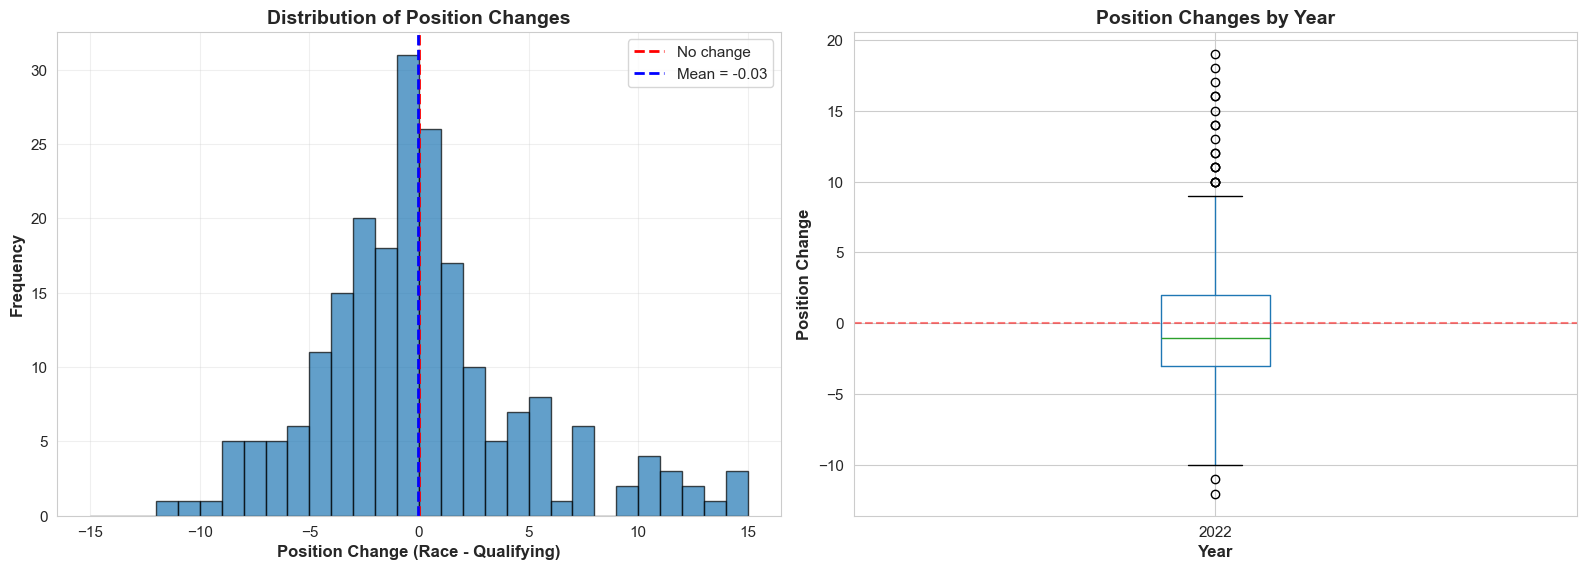

In [10]:
# Histogram of position changes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1.hist(df['position_change'], bins=range(-15, 16), edgecolor='black', alpha=0.7)
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
ax1.axvline(df['position_change'].mean(), color='blue', linestyle='--', linewidth=2, 
            label=f'Mean = {df["position_change"].mean():.2f}')
ax1.set_xlabel('Position Change (Race - Qualifying)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Position Changes', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot by year
df.boxplot(column='position_change', by='year', ax=ax2)
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Position Change', fontsize=12, fontweight='bold')
ax2.set_title('Position Changes by Year', fontsize=14, fontweight='bold')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.suptitle('')  # Remove auto-generated title

plt.tight_layout()
plt.show()

## 4. Circuit Type Analysis

Compare qualifying-race correlation across different circuit types:
- **Street circuits** (Monaco, Singapore): High walls, difficult overtaking
- **High-speed circuits** (Monza, Spa): Long straights, easier overtaking
- **Technical circuits** (Hungaroring, Barcelona): Mix of characteristics

In [11]:
# Calculate correlation by circuit type
circuit_correlations = {}
circuit_stats = []

for circuit_type in df['circuit_type'].unique():
    subset = df[df['circuit_type'] == circuit_type]
    corr, p_val = stats.spearmanr(subset['quali_pos'], subset['race_pos'])
    circuit_correlations[circuit_type] = corr
    
    circuit_stats.append({
        'Circuit Type': circuit_type.capitalize(),
        'Correlation': f"{corr:.3f}",
        'Observations': len(subset),
        'Mean Position Change': f"{subset['position_change'].mean():.2f}",
        'Std Position Change': f"{subset['position_change'].std():.2f}"
    })

circuit_df = pd.DataFrame(circuit_stats)
print("\nCorrelation by Circuit Type")
print("="*70)
print(circuit_df.to_string(index=False))


Correlation by Circuit Type
Circuit Type Correlation  Observations Mean Position Change Std Position Change
   Technical       0.467           100                 0.00                5.98
      Street       0.643            79                -0.08                4.90
  High_speed       0.563            40                 0.00                5.46


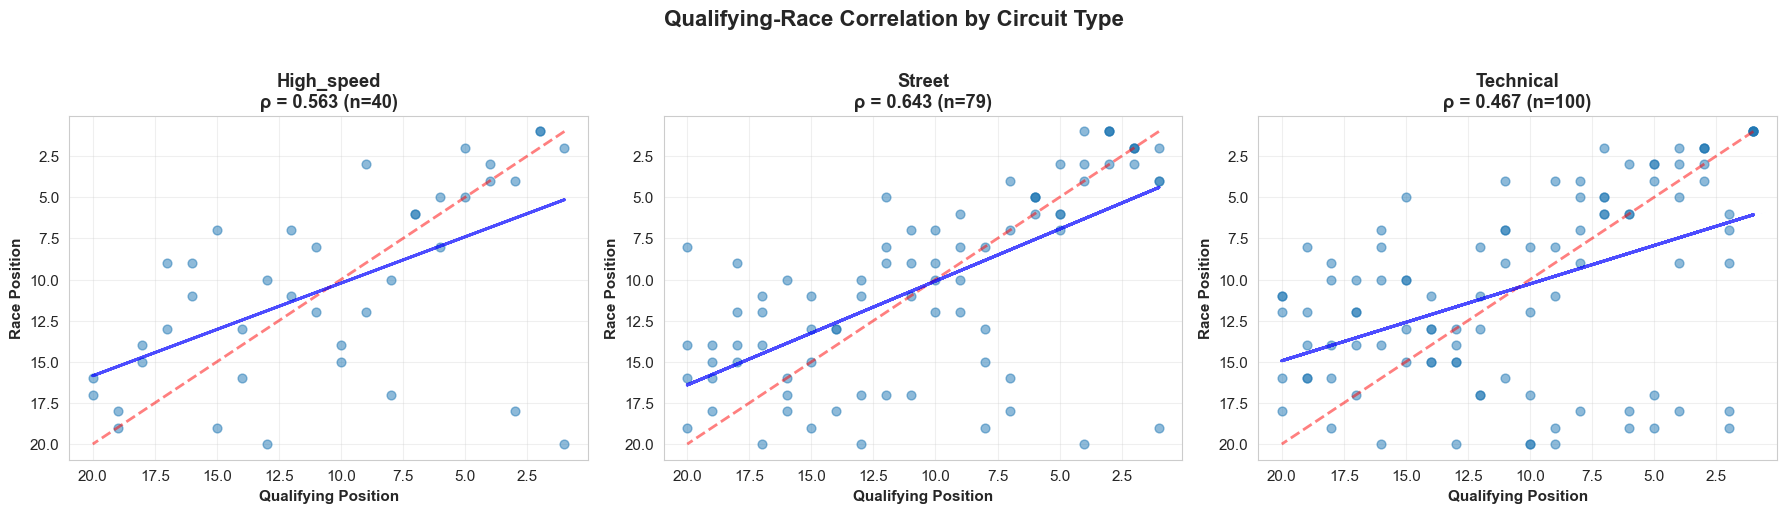

In [12]:
# Visualize correlation by circuit type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, circuit_type in enumerate(sorted(df['circuit_type'].unique())):
    subset = df[df['circuit_type'] == circuit_type]
    corr = circuit_correlations[circuit_type]
    
    axes[idx].scatter(subset['quali_pos'], subset['race_pos'], alpha=0.5, s=40)
    axes[idx].plot([1, 20], [1, 20], 'r--', linewidth=2, alpha=0.5)
    
    # Trend line
    z = np.polyfit(subset['quali_pos'], subset['race_pos'], 1)
    p = np.poly1d(z)
    axes[idx].plot(subset['quali_pos'], p(subset['quali_pos']), 'b-', linewidth=2, alpha=0.7)
    
    axes[idx].set_xlabel('Qualifying Position', fontweight='bold')
    axes[idx].set_ylabel('Race Position', fontweight='bold')
    axes[idx].set_title(f'{circuit_type.capitalize()}\nρ = {corr:.3f} (n={len(subset)})', 
                        fontweight='bold')
    axes[idx].invert_xaxis()
    axes[idx].invert_yaxis()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Qualifying-Race Correlation by Circuit Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

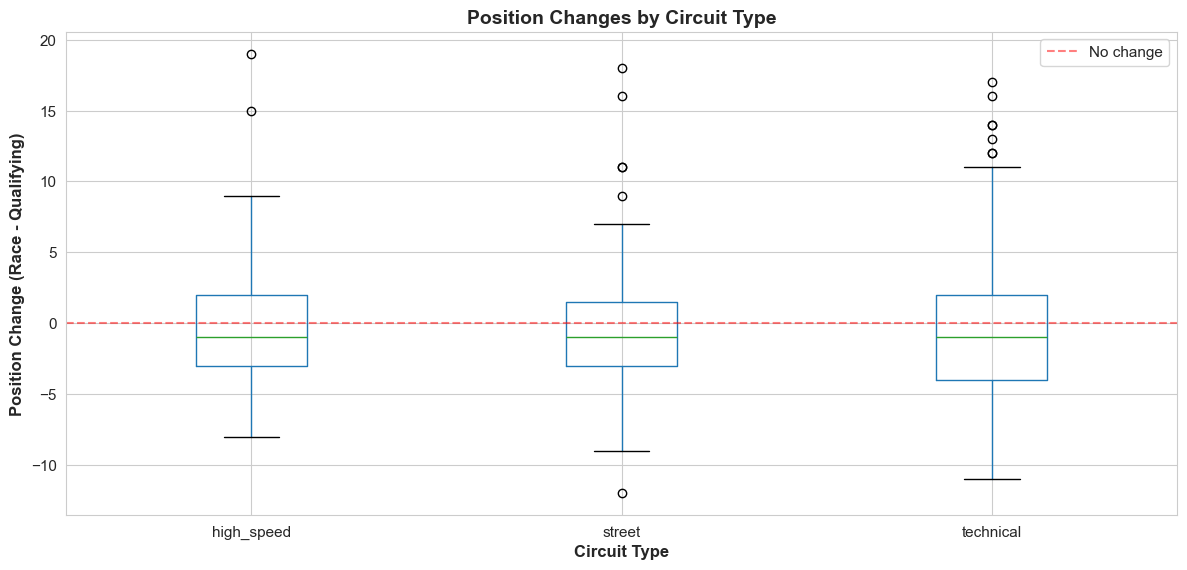

In [13]:
# Box plot: Position changes by circuit type
fig, ax = plt.subplots(figsize=(12, 6))

df.boxplot(column='position_change', by='circuit_type', ax=ax)
ax.set_xlabel('Circuit Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Position Change (Race - Qualifying)', fontsize=12, fontweight='bold')
ax.set_title('Position Changes by Circuit Type', fontsize=14, fontweight='bold')
ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='No change')
ax.legend()
plt.suptitle('')  # Remove auto title

plt.tight_layout()
plt.show()

## 5. Pole Position Analysis

Examine how often pole position (P1 in qualifying) converts to race victory.

In [14]:
# Pole position conversion rate
pole_sitters = df[df['quali_pos'] == 1]
pole_wins = pole_sitters[pole_sitters['race_pos'] == 1]

conversion_rate = len(pole_wins) / len(pole_sitters) * 100

print(f"Pole Position Conversion Analysis (2022-2024)")
print(f"="*60)
print(f"Total races: {len(pole_sitters)}")
print(f"Pole to victory: {len(pole_wins)}")
print(f"Conversion rate: {conversion_rate:.1f}%")
print(f"\nPole position finishing positions:")
print(pole_sitters['race_pos'].value_counts().sort_index())

Pole Position Conversion Analysis (2022-2024)
Total races: 11
Pole to victory: 5
Conversion rate: 45.5%

Pole position finishing positions:
race_pos
1     5
2     2
4     2
19    1
20    1
Name: count, dtype: int64


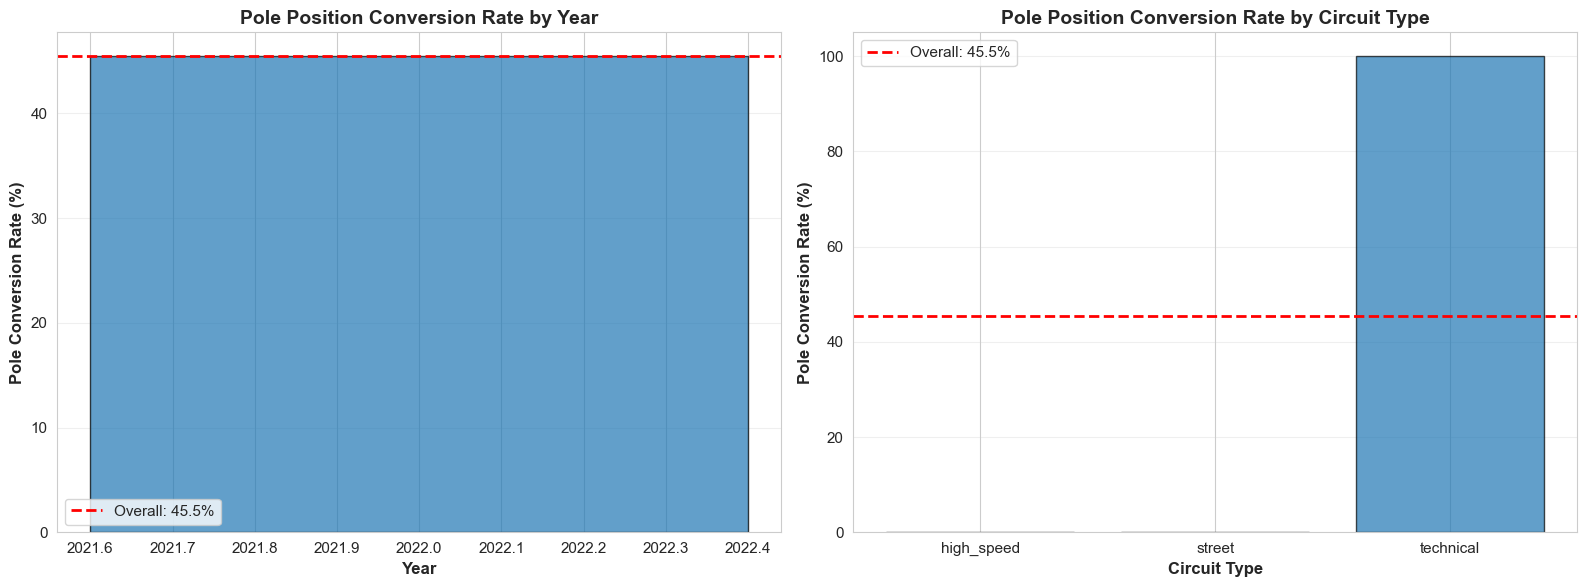

In [15]:
# Pole conversion by year and circuit type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# By year
pole_by_year = pole_sitters.groupby('year').apply(
    lambda x: (x['race_pos'] == 1).sum() / len(x) * 100
)
ax1.bar(pole_by_year.index, pole_by_year.values, edgecolor='black', alpha=0.7)
ax1.axhline(conversion_rate, color='red', linestyle='--', linewidth=2, 
            label=f'Overall: {conversion_rate:.1f}%')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Pole Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Pole Position Conversion Rate by Year', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# By circuit type
pole_by_circuit = pole_sitters.groupby('circuit_type').apply(
    lambda x: (x['race_pos'] == 1).sum() / len(x) * 100
)
ax2.bar(pole_by_circuit.index, pole_by_circuit.values, edgecolor='black', alpha=0.7)
ax2.axhline(conversion_rate, color='red', linestyle='--', linewidth=2, 
            label=f'Overall: {conversion_rate:.1f}%')
ax2.set_xlabel('Circuit Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Pole Conversion Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Pole Position Conversion Rate by Circuit Type', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Year-over-Year Comparison

Analyze if correlation changes across years (2022 regulation impact).

In [16]:
# Correlation by year
year_stats = []

for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    corr, p_val = stats.spearmanr(subset['quali_pos'], subset['race_pos'])
    
    year_stats.append({
        'Year': year,
        'Correlation': f"{corr:.3f}",
        'Races': subset['race'].nunique(),
        'Observations': len(subset),
        'Mean Pos Change': f"{subset['position_change'].mean():.2f}",
        'Std Pos Change': f"{subset['position_change'].std():.2f}"
    })

year_df = pd.DataFrame(year_stats)
print("\nYear-by-Year Analysis")
print("="*80)
print(year_df.to_string(index=False))


Year-by-Year Analysis
 Year Correlation  Races  Observations Mean Pos Change Std Pos Change
 2022       0.548     11           219           -0.03           5.49


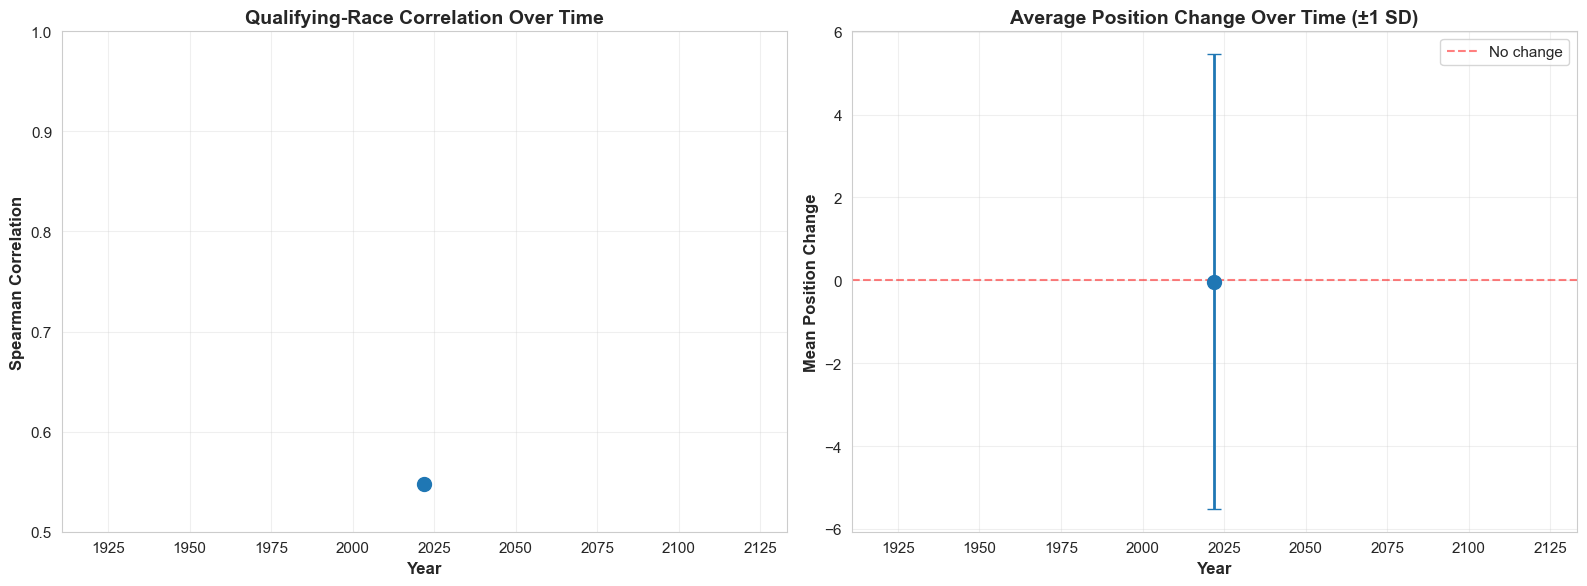

In [17]:
# Visualize trends over years
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Correlation trend
year_corrs = [float(s['Correlation']) for s in year_stats]
years = [s['Year'] for s in year_stats]

ax1.plot(years, year_corrs, marker='o', linewidth=2, markersize=10)
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Spearman Correlation', fontsize=12, fontweight='bold')
ax1.set_title('Qualifying-Race Correlation Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.5, 1.0])

# Position change variance
mean_changes = [float(s['Mean Pos Change']) for s in year_stats]
std_changes = [float(s['Std Pos Change']) for s in year_stats]

ax2.errorbar(years, mean_changes, yerr=std_changes, marker='o', 
             linewidth=2, markersize=10, capsize=5)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5, label='No change')
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Position Change', fontsize=12, fontweight='bold')
ax2.set_title('Average Position Change Over Time (±1 SD)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Grid Position Analysis

Examine correlation strength for different starting positions (front vs. midfield vs. back).

In [18]:
# Create grid position groups
df['grid_group'] = pd.cut(df['quali_pos'], 
                          bins=[0, 5, 10, 20], 
                          labels=['Front (P1-5)', 'Midfield (P6-10)', 'Back (P11+)'])

# Calculate stats by grid group
grid_stats = []

for group in df['grid_group'].cat.categories:
    subset = df[df['grid_group'] == group]
    
    grid_stats.append({
        'Starting Position': group,
        'Observations': len(subset),
        'Mean Finish': f"{subset['race_pos'].mean():.2f}",
        'Mean Pos Change': f"{subset['position_change'].mean():.2f}",
        'Positions Gained (%)': f"{(subset['position_change'] < 0).sum() / len(subset) * 100:.1f}%"
    })

grid_df = pd.DataFrame(grid_stats)
print("\nPerformance by Starting Grid Position")
print("="*80)
print(grid_df.to_string(index=False))


Performance by Starting Grid Position
Starting Position  Observations Mean Finish Mean Pos Change Positions Gained (%)
     Front (P1-5)            55        5.71            2.71                32.7%
 Midfield (P6-10)            55        9.98            1.98                43.6%
      Back (P11+)           109       13.09           -2.42                70.6%


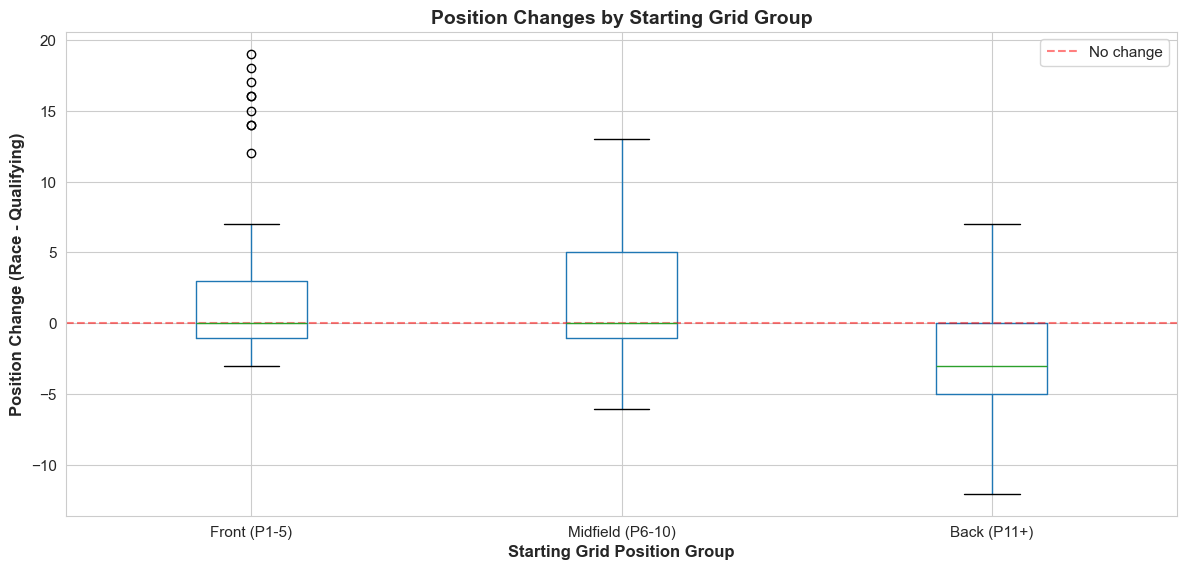

In [19]:
# Visualize position changes by grid group
fig, ax = plt.subplots(figsize=(12, 6))

df.boxplot(column='position_change', by='grid_group', ax=ax)
ax.set_xlabel('Starting Grid Position Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Position Change (Race - Qualifying)', fontsize=12, fontweight='bold')
ax.set_title('Position Changes by Starting Grid Group', fontsize=14, fontweight='bold')
ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='No change')
ax.legend()
plt.suptitle('')

plt.tight_layout()
plt.show()

## 8. Key Findings Summary

Summarize the main insights from the exploratory analysis.

In [20]:
print("\n" + "="*80)
print("KEY FINDINGS: Qualifying-Race Performance Correlation (2022-2024)")
print("="*80)

print(f"\n1. OVERALL CORRELATION")
print(f"   - Spearman correlation: {overall_corr:.3f}")
print(f"   - Interpretation: {'Strong' if overall_corr > 0.7 else 'Moderate'} positive relationship")
print(f"   - Qualifying position is {'highly' if overall_corr > 0.7 else 'moderately'} predictive of race outcome")

print(f"\n2. CIRCUIT TYPE DIFFERENCES")
for circuit_type, corr in sorted(circuit_correlations.items(), key=lambda x: x[1], reverse=True):
    print(f"   - {circuit_type.capitalize()}: ρ = {corr:.3f}")

print(f"\n3. POLE POSITION CONVERSION")
print(f"   - Conversion rate: {conversion_rate:.1f}%")
print(f"   - {len(pole_wins)} out of {len(pole_sitters)} pole sitters won the race")

print(f"\n4. POSITION CHANGES")
print(f"   - Mean position change: {df['position_change'].mean():.2f}")
print(f"   - Drivers maintaining position: {(df['position_change'] == 0).sum()/len(df)*100:.1f}%")
print(f"   - Drivers gaining positions: {(df['position_change'] < 0).sum()/len(df)*100:.1f}%")
print(f"   - Drivers losing positions: {(df['position_change'] > 0).sum()/len(df)*100:.1f}%")

print(f"\n5. YEAR-OVER-YEAR TRENDS")
for stat in year_stats:
    print(f"   - {stat['Year']}: ρ = {stat['Correlation']} ({stat['Races']} races)")

print("\n" + "="*80)
print("\nNext Steps:")
print("- Conduct formal statistical tests (ordinal logistic regression)")
print("- Include 2018-2021 data for pre/post-2022 regulation comparison")
print("- Analyze specific circuits with extreme overtaking difficulty")
print("- Control for team performance differences using multilevel models")
print("="*80)


KEY FINDINGS: Qualifying-Race Performance Correlation (2022-2024)

1. OVERALL CORRELATION
   - Spearman correlation: 0.548
   - Interpretation: Moderate positive relationship
   - Qualifying position is moderately predictive of race outcome

2. CIRCUIT TYPE DIFFERENCES
   - Street: ρ = 0.643
   - High_speed: ρ = 0.563
   - Technical: ρ = 0.467

3. POLE POSITION CONVERSION
   - Conversion rate: 45.5%
   - 5 out of 11 pole sitters won the race

4. POSITION CHANGES
   - Mean position change: -0.03
   - Drivers maintaining position: 11.9%
   - Drivers gaining positions: 54.3%
   - Drivers losing positions: 33.8%

5. YEAR-OVER-YEAR TRENDS
   - 2022: ρ = 0.548 (11 races)


Next Steps:
- Conduct formal statistical tests (ordinal logistic regression)
- Include 2018-2021 data for pre/post-2022 regulation comparison
- Analyze specific circuits with extreme overtaking difficulty
- Control for team performance differences using multilevel models


## 9. Save Processed Data

Export cleaned data for future analysis.

In [21]:
# Save to CSV
output_file = 'data_rq1_qualifying_race.csv'
df.to_csv(output_file, index=False)
print(f"\nData saved to: {output_file}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")


Data saved to: data_rq1_qualifying_race.csv
Rows: 219, Columns: 10
